# Debiased inference デモンストレーション

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import KFold
from pathlib import Path
from datetime import datetime

In [15]:
# results フォルダの下に yymmdd の日付フォルダを作る
date_str = datetime.now().strftime("%y%m%d")
save_dir = Path("results") / date_str
save_dir.mkdir(parents=True, exist_ok=True)

print(save_dir)  # 例: results/260320

results\260320


## 1. 人工データ生成

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def make_data(n=800, p=5, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))

    # 真の propensity score: 非線形
    e = sigmoid(
        0.8 * np.sin(X[:, 0])
        + 0.6 * X[:, 1]
        - 0.4 * X[:, 2] ** 2
    )

    # treatment
    A = rng.binomial(1, e)

    # 真の treatment effect
    tau_x = 1.0 + 0.5 * np.tanh(X[:, 3])

    # ベースライン回帰
    m0 = 1.0 + np.sin(X[:, 0]) + 0.5 * X[:, 1] ** 2 - 0.5 * X[:, 2]

    # outcome
    Y = m0 + A * tau_x + rng.normal(scale=1.0, size=n)

    # X4 が対称分布なので E[tanh(X4)] = 0
    true_ate = 1.0

    return X, A, Y, true_ate

## 2. nuisance の cross-fitting 推定

In [7]:
def fit_nuisance_crossfit(X, A, Y, n_splits=2, seed=0):
    n = len(Y)

    e_hat = np.zeros(n)
    m0_hat = np.zeros(n)
    m1_hat = np.zeros(n)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        A_tr, Y_tr = A[train_idx], Y[train_idx]

        rs = seed + fold

        # propensity model
        clf = RandomForestClassifier(
            n_estimators=30,
            max_depth=3,
            min_samples_leaf=20,
            random_state=rs,
            n_jobs=1,
        )
        clf.fit(X_tr, A_tr)
        e_hat[test_idx] = clf.predict_proba(X_te)[:, 1]

        # outcome regressions
        reg0 = RandomForestRegressor(
            n_estimators=30,
            max_depth=3,
            min_samples_leaf=20,
            random_state=rs,
            n_jobs=1,
        )
        reg1 = RandomForestRegressor(
            n_estimators=30,
            max_depth=3,
            min_samples_leaf=20,
            random_state=rs,
            n_jobs=1,
        )

        reg0.fit(X_tr[A_tr == 0], Y_tr[A_tr == 0])
        reg1.fit(X_tr[A_tr == 1], Y_tr[A_tr == 1])

        m0_hat[test_idx] = reg0.predict(X_te)
        m1_hat[test_idx] = reg1.predict(X_te)

    # 安定化のため clip
    e_hat = np.clip(e_hat, 0.02, 0.98)

    return e_hat, m0_hat, m1_hat

## 3. plugin と debiased(EIF) 推定量

In [8]:
def estimate_ate(X, A, Y, seed=0):
    e_hat, m0_hat, m1_hat = fit_nuisance_crossfit(X, A, Y, seed=seed)

    # 単純 plugin
    tau_plugin = np.mean(m1_hat - m0_hat)

    # EIF-based debiased estimator (AIPW / one-step)
    pseudo = (
        (m1_hat - m0_hat)
        + A * (Y - m1_hat) / e_hat
        - (1 - A) * (Y - m0_hat) / (1 - e_hat)
    )
    tau_dr = np.mean(pseudo)

    # EIF に基づく標準誤差
    infl = pseudo - tau_dr
    se_dr = np.std(infl, ddof=1) / np.sqrt(len(Y))
    ci_dr = (tau_dr - 1.96 * se_dr, tau_dr + 1.96 * se_dr)

    return {
        "plugin": tau_plugin,
        "dr": tau_dr,
        "se_dr": se_dr,
        "ci_dr": ci_dr,
    }

## 4. 単発実行

In [9]:
X, A, Y, true_ate = make_data(seed=1)
res = estimate_ate(X, A, Y, seed=1)

print("Single run")
print(f"True ATE        : {true_ate:.4f}")
print(f"Plugin estimate : {res['plugin']:.4f}")
print(f"DR estimate     : {res['dr']:.4f}")
print(f"DR std. error   : {res['se_dr']:.4f}")
print(f"DR 95% CI       : ({res['ci_dr'][0]:.4f}, {res['ci_dr'][1]:.4f})")

Single run
True ATE        : 1.0000
Plugin estimate : 1.0590
DR estimate     : 1.0238
DR std. error   : 0.0977
DR 95% CI       : (0.8323, 1.2153)


## 5. 繰り返しシミュレーション

In [10]:
n_rep = 500
plugin_list = np.zeros(n_rep)
dr_list = np.zeros(n_rep)
cover_dr = np.zeros(n_rep, dtype=bool)

# ループ！
for r in tqdm.tqdm(range(n_rep)):
    X, A, Y, true_ate = make_data(seed=r)
    res = estimate_ate(X, A, Y, seed=r)

    plugin_list[r] = res["plugin"]
    dr_list[r] = res["dr"]
    cover_dr[r] = (res["ci_dr"][0] <= true_ate <= res["ci_dr"][1])

# 結果まとめ
def summarize(estimates, true_value):
    err = estimates - true_value
    return {
        "mean": np.mean(estimates),
        "bias": np.mean(err),
        "sd": np.std(estimates, ddof=1),
        "rmse": np.sqrt(np.mean(err ** 2)),
    }

plugin_summary = summarize(plugin_list, true_ate) # プラグイン推定量
dr_summary = summarize(dr_list, true_ate) # Debiased推定量

print("\nRepeated simulation")
print("Plugin summary")
for k, v in plugin_summary.items():
    print(f"  {k:>4}: {v:.4f}")

print("DR summary")
for k, v in dr_summary.items():
    print(f"  {k:>4}: {v:.4f}")

print(f"DR 95% CI coverage: {np.mean(cover_dr):.3f}")

100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [02:47<00:00,  2.99it/s]


Repeated simulation
Plugin summary
  mean: 1.0612
  bias: 0.0612
    sd: 0.0940
  rmse: 0.1120
DR summary
  mean: 1.0165
  bias: 0.0165
    sd: 0.0914
  rmse: 0.0928
DR 95% CI coverage: 0.938


## 6. 図示

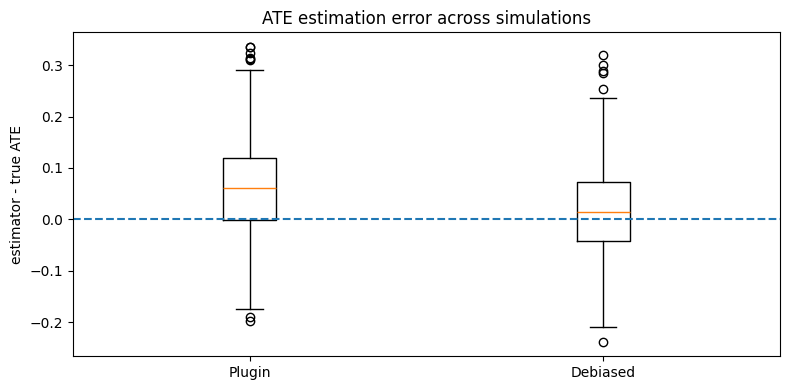

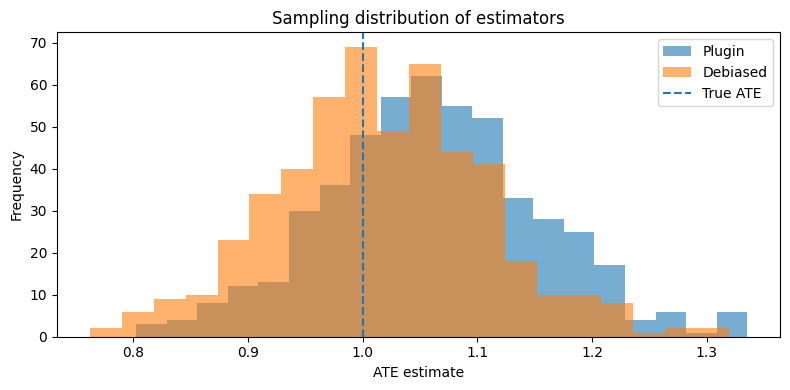

In [16]:
plugin_err = plugin_list - true_ate
dr_err = dr_list - true_ate

plt.figure(figsize=(8, 4))
plt.boxplot([plugin_err, dr_err], tick_labels=["Plugin", "Debiased"])
plt.axhline(0.0, linestyle="--")
plt.ylabel("estimator - true ATE")
plt.title("ATE estimation error across simulations")
plt.tight_layout()
plt.savefig(save_dir / "boxplot_error.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(plugin_list, bins=20, alpha=0.6, label="Plugin")
plt.hist(dr_list, bins=20, alpha=0.6, label="Debiased")
plt.axvline(true_ate, linestyle="--", label="True ATE")
plt.xlabel("ATE estimate")
plt.ylabel("Frequency")
plt.title("Sampling distribution of estimators")
plt.legend()
plt.tight_layout()
plt.savefig(save_dir / "hist_ate.png", dpi=300, bbox_inches="tight")
plt.show()